# ***SPUE Simulation***

In [117]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.compiler import transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from spue_circuit import build_prepare_select_prepare_dag

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "axes.linewidth": 1.8,        
    "axes.labelsize": 18,
    "axes.titlesize": 15,
    "xtick.labelsize": 16,
    "ytick.labelsize": 14,
})

In [118]:
n =  5 # Simulation for n=5
qc = build_prepare_select_prepare_dag(n)

sim = AerSimulator()
qc_meas = qc.copy()
qc_meas.measure_all()

tqc = transpile(qc_meas, sim, optimization_level=1)

# remove measurements → unitary only
qc_u = tqc.remove_final_measurements(inplace=False)

print("=== Decomposed circuit metrics ===")
print(f"Num qubits: {qc_u.num_qubits}")
print(f"Gate count (size): {qc_u.size()}")
print(f"Depth: {qc_u.depth()}")
print("Ops:", qc_u.count_ops())

=== Decomposed circuit metrics ===
Num qubits: 16
Gate count (size): 124
Depth: 79
Ops: OrderedDict({'ccx': 58, 'x': 36, 'cx': 10, 'u3': 8, 'h': 5, 'ccz': 5, 'ry': 2})


***EXACT STATEVECTOR ANALYSIS***

In [119]:
sv = Statevector.from_instruction(qc_u)

n_q   = n + 1 # q + flag
n_b   = n
n_tot = qc_u.num_qubits

keep = []
success_prob = 0.0

for i, amp in enumerate(sv.data):
    if abs(amp) < 1e-12:
        continue

    bits = f"{i:0{n_tot}b}"

    #post-select b = 0^n AND flag = 0
    q_bits = bits[-n_q:]

    if q_bits != "0"*n_q:
        continue

    b_bits = bits[-(n_q + n_b):-n_q]
    keep.append((int(b_bits, 2), amp))
    success_prob += abs(amp)**2

pairs = sorted(keep, key=lambda x: x[0])

print(f"\nSuccess probability (SV) = {success_prob:.6f}")


Success probability (SV) = 0.399731


***SAMPLING***

In [120]:
shots = 20_000
res = sim.run(tqc, shots=shots).result()
counts = res.get_counts()
total = sum(counts.values())

filtered = {}

for bits, ct in counts.items():
    q_bits = bits[-n_q:]

    if q_bits != "0"*n_q:
        continue

    b_bits = bits[-(n_q + n_b):-n_q]
    filtered[b_bits] = filtered.get(b_bits, 0) + ct

kept = sum(filtered.values())

print("\nShot results (post-selected):")
for k in sorted(filtered, key=lambda s: int(s, 2)):
    print(f"{int(k,2):02d}: {filtered[k]}")

emp_success_prob = kept / total

print(f"\nEmpirical success probability ≈ {emp_success_prob:.6f}")


Shot results (post-selected):
00: 643
01: 613
02: 583
03: 533
04: 518
05: 442
06: 424
07: 413
08: 398
09: 330
10: 334
11: 309
12: 283
13: 276
14: 251
15: 216
16: 194
17: 187
18: 195
19: 134
20: 153
21: 128
22: 111
23: 90
24: 82
25: 65
26: 63
27: 42
28: 37
29: 26
30: 22
31: 19

Empirical success probability ≈ 0.405700


***PLOT |amp| vs shots***

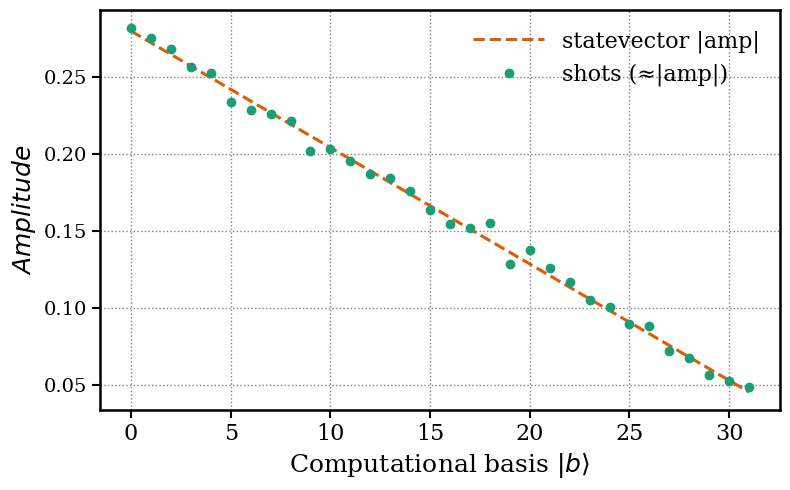

In [121]:
xs = [idx for idx, _ in pairs]

#Multiplying by 1/sqrt(p_success) to renormalize amplitudes after post-selection
ys = [abs(amp)*(1/success_prob**0.5) for _, amp in pairs]
ys_s = [
    np.sqrt(filtered.get(f"{x:0{n_b}b}", 0) / total)*(1/emp_success_prob**0.5)
    for x in xs
]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    xs, ys,
    linestyle="--",
    linewidth=2.2,
    color="#d95f02",
    label=r"statevector |amp|"
)

ax.plot(
    xs, ys_s,
    linestyle="None",
    marker="o",
    markersize=6,
    color="#1b9e77",
    label=r"shots (≈|amp|)"
)

ax.set_xlabel(r"Computational basis $|b\rangle$")
ax.set_ylabel(r"$Amplitude$")
ax.grid(True, which="both",
        linestyle=":",
        linewidth=1.0,
        color="black",
        alpha=0.5)

ax.tick_params(width=1.5, length=6)

ax.legend(frameon=False, fontsize=16, handlelength=3.2, labelspacing=0.5)

plt.tight_layout()
plt.show()

***Comparison with theoritical amp***

In [122]:
def p_n(n):
    js = np.arange(1, n + 1, dtype=float)
    a = 1.0 - 1.0 / (np.exp2(js) + 1.0)
    log_a = np.log(a)
    log_total = np.sum(log_a)
    p = 0
    for k in range(n):
        term_k = 1.0 / (np.exp2(k + 1) + 1.0)
        p += term_k * np.exp(log_total - log_a[k])
    return p


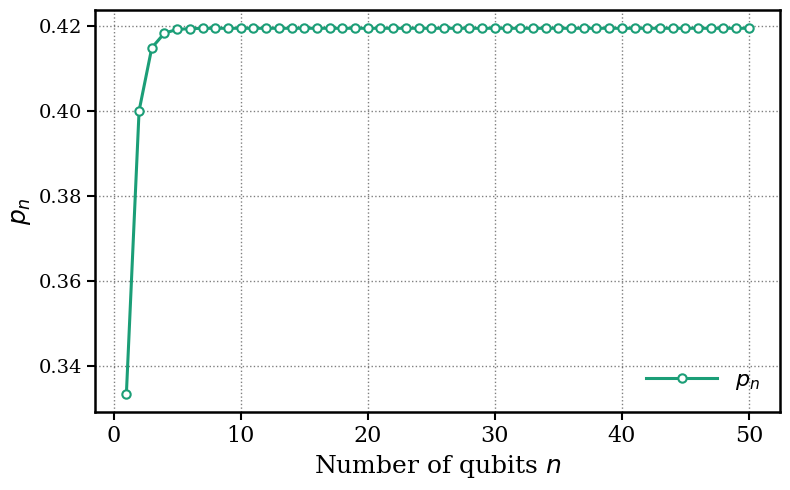

In [123]:
ns = np.arange(1, 50 + 1, 1)
ps = [p_n(n) for n in ns]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    ns, ps,
    marker="o",
    markersize=6,
    linewidth=2.2,
    color="#1b9e77",
    markerfacecolor="white",
    markeredgewidth=1.5,
    label=r"$p_n$"
)

ax.set_xlabel(r"Number of qubits $n$")
ax.set_ylabel(r"$p_n$")

ax.grid(True, which="both",
        linestyle=":",
        linewidth=1.0,
        color="black",
        alpha=0.5)

ax.tick_params(width=1.5, length=6)

ax.legend(frameon=False, fontsize=16, handlelength=3.2, labelspacing=3)

plt.tight_layout()
plt.show()

p_5 :  0.4191457054202153
Normalization coefficient :  0.6322427413473676


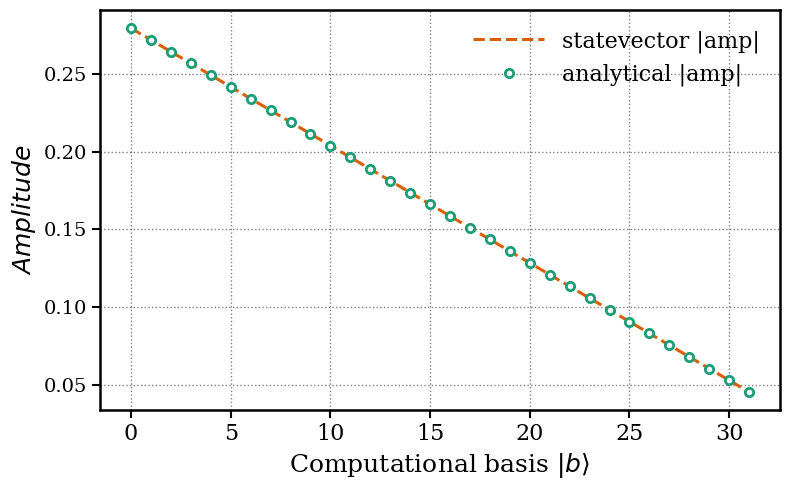

In [124]:
pn = p_n(n)
print(f"p_{n} : ",pn)

amp_with_pn_estimation = [(1-(2*pn*i)/(2**n-1))/2**(n/2) for i in range(len(ys))]
normalization_coeff = sum([amp**2 for amp in amp_with_pn_estimation])**0.5
print("Normalization coefficient : ",normalization_coeff)

analytical_amps = [amp/normalization_coeff for amp in amp_with_pn_estimation]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    xs, ys,
    linestyle="--",
    linewidth=2.2,
    color="#d95f02",
    label=r"statevector |amp|"
)

ax.plot(
    xs, analytical_amps,
    linestyle="None",
    marker="o",
    markersize=6,
    color="#1b9e77",
    markerfacecolor="white",
    markeredgewidth=2,
    label=r"analytical |amp|"
)

ax.set_xlabel(r"Computational basis $|b\rangle$")
ax.set_ylabel(r"$Amplitude$")
ax.grid(True, which="both",
        linestyle=":",
        linewidth=1.0,
        color="black",
        alpha=0.5)

ax.tick_params(width=1.5, length=6)

ax.legend(frameon=False, fontsize=16, handlelength=3.2, labelspacing=0.5)

plt.tight_layout()
plt.show()